## MNIST from scratch

This project builds a simple 2 layer neural network to classify MNIST images using only NumPy.
No deep learning frameworks have been used in this implementation.

In [66]:
from model import NeuralNetwork
from utils import load_images, load_labels

X_train = load_images("data/train-images.idx3-ubyte")
y_train = load_labels("data/train-labels.idx1-ubyte")

X_test = load_images(r"data\t10k-images.idx3-ubyte")
y_test = load_labels(r"data\t10k-labels.idx1-ubyte")

model = NeuralNetwork()

print(X_train.shape, f"<- {X_train.shape[0]} examples of 28x28 images flattened into vectors of size {X_train.shape[1]}")
print(X_train[0].shape, "<- Shape of one example (rank 1 array)")

(60000, 784) <- 60000 examples of 28x28 images flattened into vectors of size 784
(784,) <- Shape of one example (rank 1 array)


In [2]:
A2 = model.forward(X_train)
dW1, db1, dW2, db2 = model.backward(X_train, y_train)

In [3]:
model.debug_shapes()

=== INITIAL WEIGHTES AND BIASES ===
W1 : (784, 128)
b1 : (1, 128)

W2 : (128, 10)
b2 : (1, 10)

=== FORWARD PASS ===
Z1 : (60000, 128)
A1 : (60000, 128)
Z2 : (60000, 10)
A2 : (60000, 10)

=== BACKWARD PASS ===
m: 60000

dZ2: (60000, 10)
dW2: (128, 10)
db2: (1, 10)

dA1: (60000, 128)
dZ1: (60000, 128)

dW1: (784, 128)
db1: (1, 128)


---
Let's run a few examples

In [ ]:
from model import NeuralNetwork


def plot_helper(epochs, learning_rate):

    import matplotlib.pyplot as plt
    import numpy as np
    from loss import cross_entropy_loss
    from utils import accuracy
    from sklearn.metrics import confusion_matrix

    # Fresh model every run
    model = NeuralNetwork()

    loss_history = []
    train_accuracies = []
    test_accuracies = []

    # ==========================
    # Training Loop
    # ==========================

    for epoch in range(epochs):

        # Forward pass
        y_pred = model.forward(X_train)

        # Metrics before update
        loss = cross_entropy_loss(y_pred, y_train)

        # Backward pass
        dW1, db1, dW2, db2 = model.backward(
            X_train,
            y_train,
        )

        # Gradient descent step
        model.update_parameters(
            dW1,
            db1,
            dW2,
            db2,
            learning_rate,
        )

        # Evaluate after update
        train_acc = accuracy(
            model.forward(X_train),
            y_train,
        )

        test_acc = accuracy(
            model.forward(X_test),
            y_test,
        )

        loss_history.append(loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        if epochs <= 20:
            print(
                f"Epoch {epoch+1} | "
                f"Loss: {loss:.4f} | "
                f"Train: {train_acc:.4f} | "
                f"Test: {test_acc:.4f}"
            )
        else:
            if (epoch + 1) % 10 == 0:
                print(
                    f"Epoch {epoch+1} | "
                    f"Loss: {loss:.4f} | "
                    f"Train: {train_acc:.4f} | "
                    f"Test: {test_acc:.4f}"
                )

    # ==========================
    # Loss + Accuracy Plots
    # ==========================

    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss_history)
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    # Train/Test Accuracy
    plt.subplot(1, 2, 2)

    plt.plot(
        epochs_range,
        train_accuracies,
        label="Train Accuracy",
        color="blue",
    )

    plt.plot(
        epochs_range,
        test_accuracies,
        label="Test Accuracy",
        color="orange",
    )

    plt.title("Train vs Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # ==========================
    # Most Confident Mistakes
    # ==========================

    probabilities = model.forward(X_test)

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    wrong_idx = np.where(predictions != y_test)[0]

    confidence = probabilities[wrong_idx].max(axis=1)

    sorted_wrong_idx = wrong_idx[np.argsort(confidence)[::-1]]

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(12, 6),
    )

    for ax, idx in zip(
        axes.flat,
        sorted_wrong_idx[:10],
    ):

        predicted_class = predictions[idx]
        true_class = y_test[idx]

        predicted_confidence = probabilities[
            idx,
            predicted_class,
        ]

        ax.imshow(
            X_test[idx].reshape(28, 28),
            cmap="gray",
        )

        ax.set_title(
            f"P:{predicted_class} " f"({predicted_confidence:.2%})\n" f"T:{true_class}"
        )

        ax.axis("off")

    plt.suptitle("Most Confident Wrong Predictions")

    plt.tight_layout()
    plt.show()

    # ==========================
    # Confusion Matrix
    # ==========================

    cm = confusion_matrix(
        y_test,
        predictions,
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    digits = np.arange(10)

    plt.xticks(digits)
    plt.yticks(digits)

    plt.colorbar()

    for i in range(10):
        for j in range(10):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()

### For epochs = 10 | learning rate = 0.1

Epoch 1 | Loss: 2.3028 | Train: 0.1058 | Test: 0.1000
Epoch 2 | Loss: 2.3018 | Train: 0.1651 | Test: 0.1606
Epoch 3 | Loss: 2.3007 | Train: 0.2343 | Test: 0.2274
Epoch 4 | Loss: 2.2997 | Train: 0.2887 | Test: 0.2852
Epoch 5 | Loss: 2.2986 | Train: 0.3269 | Test: 0.3292
Epoch 6 | Loss: 2.2975 | Train: 0.3580 | Test: 0.3615
Epoch 7 | Loss: 2.2963 | Train: 0.3826 | Test: 0.3846
Epoch 8 | Loss: 2.2951 | Train: 0.4021 | Test: 0.4046
Epoch 9 | Loss: 2.2938 | Train: 0.4173 | Test: 0.4189
Epoch 10 | Loss: 2.2925 | Train: 0.4295 | Test: 0.4331


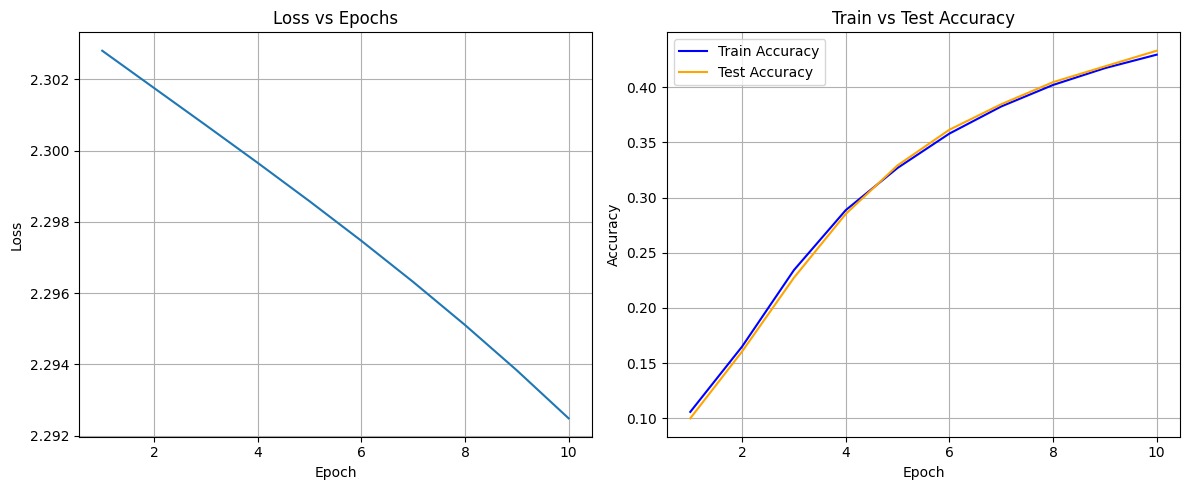

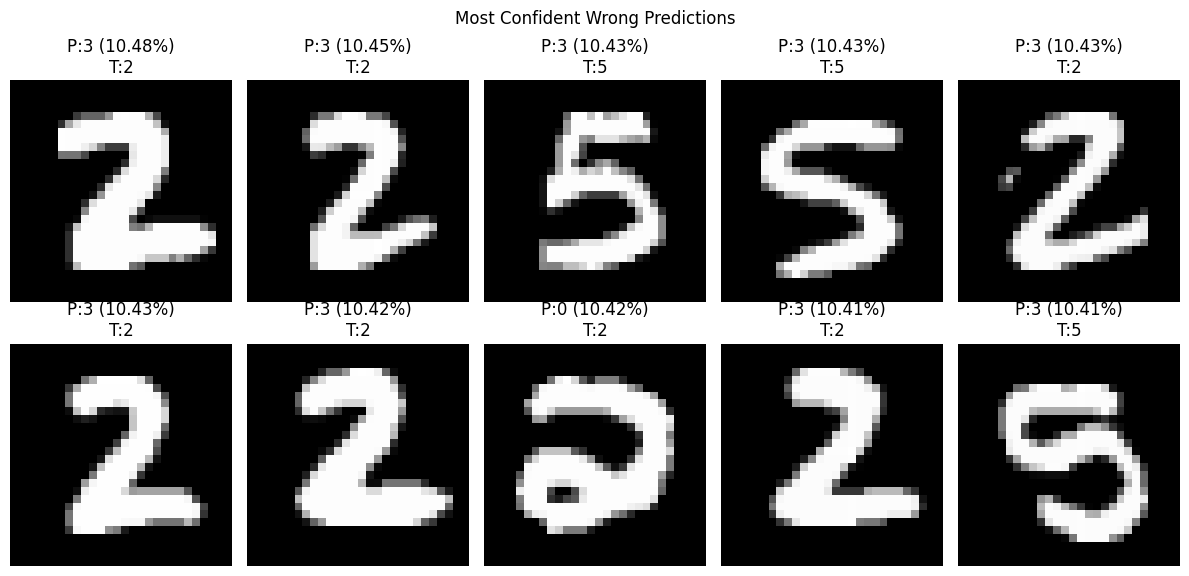

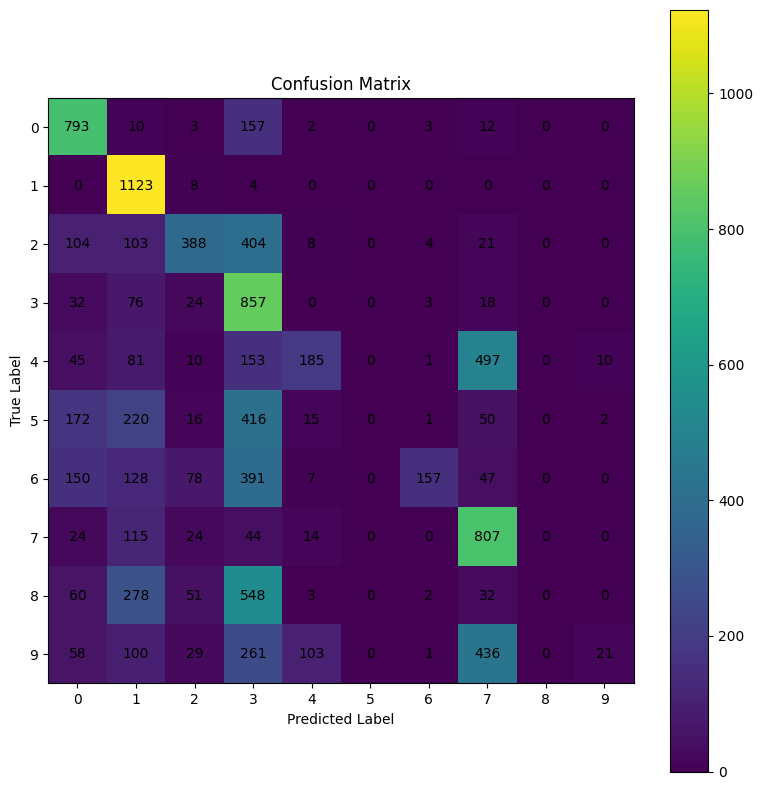

In [103]:
plot_helper(epochs=10, learning_rate=0.1)

### For epochs = 10 | Learning rate = 0.01

Epoch 1 | Loss: 2.3023 | Train: 0.1021 | Test: 0.1045
Epoch 2 | Loss: 2.3022 | Train: 0.1072 | Test: 0.1092
Epoch 3 | Loss: 2.3020 | Train: 0.1123 | Test: 0.1125
Epoch 4 | Loss: 2.3019 | Train: 0.1172 | Test: 0.1170
Epoch 5 | Loss: 2.3018 | Train: 0.1225 | Test: 0.1229
Epoch 6 | Loss: 2.3016 | Train: 0.1279 | Test: 0.1284
Epoch 7 | Loss: 2.3015 | Train: 0.1332 | Test: 0.1329
Epoch 8 | Loss: 2.3014 | Train: 0.1381 | Test: 0.1391
Epoch 9 | Loss: 2.3012 | Train: 0.1429 | Test: 0.1440
Epoch 10 | Loss: 2.3011 | Train: 0.1479 | Test: 0.1491


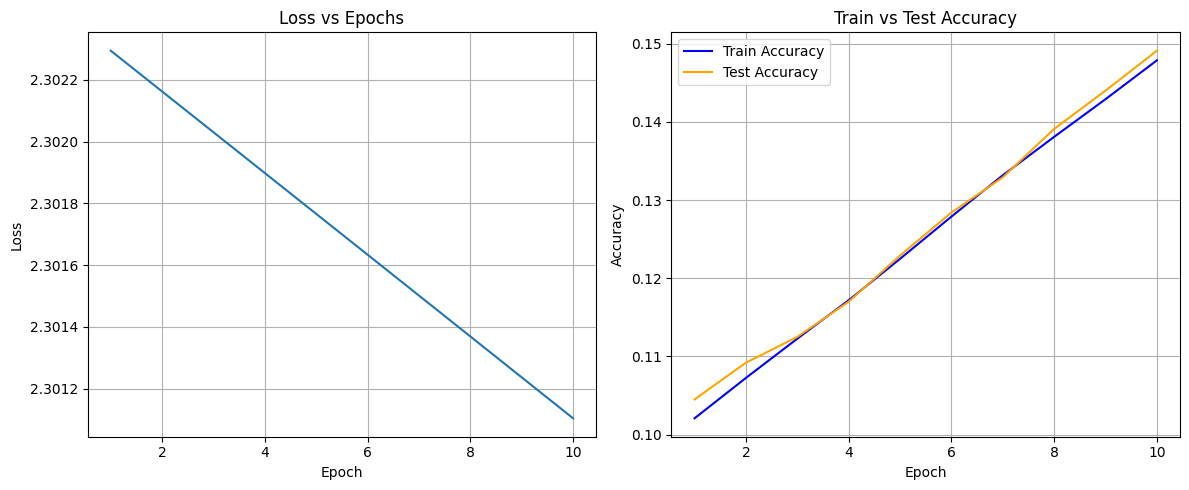

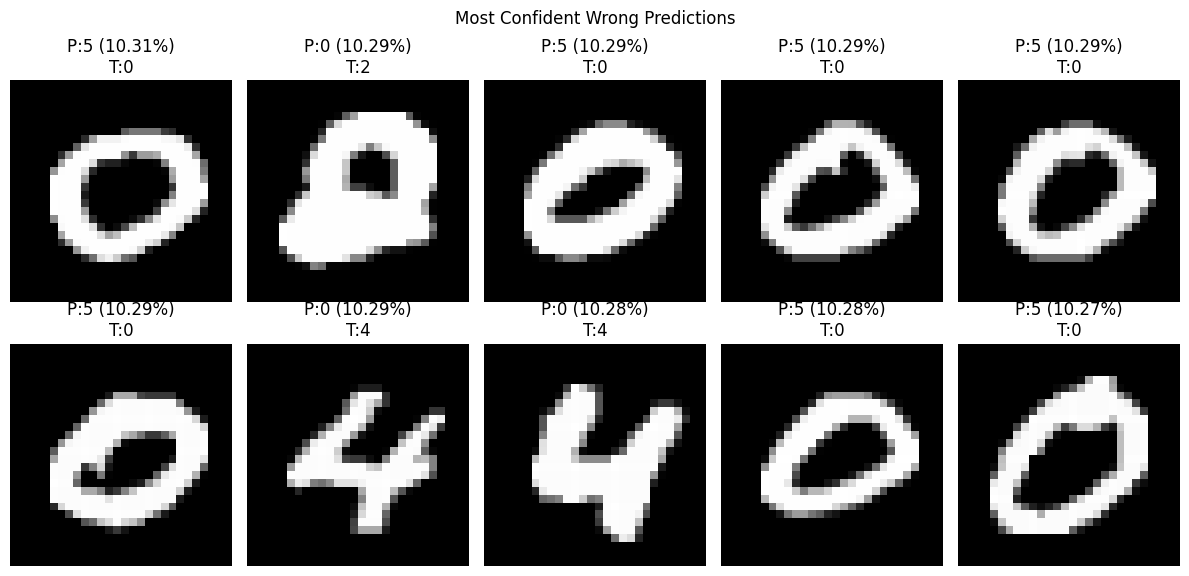

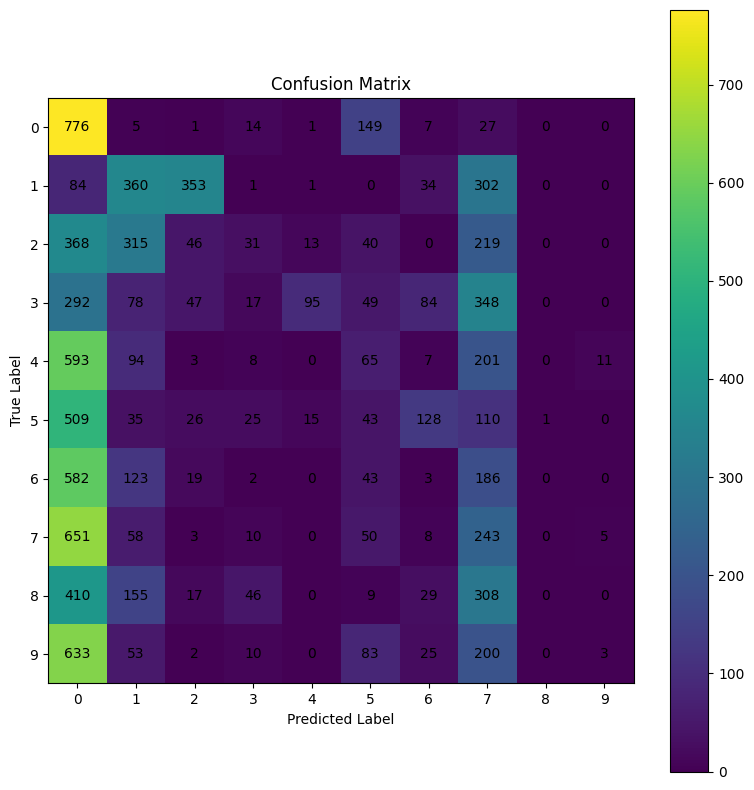

In [104]:
plot_helper(10, 0.01)

### For epochs = 20 | Learning rate = 0.1

Epoch 1 | Loss: 2.3021 | Train: 0.1626 | Test: 0.1519
Epoch 2 | Loss: 2.3010 | Train: 0.1969 | Test: 0.1898
Epoch 3 | Loss: 2.2999 | Train: 0.2447 | Test: 0.2395
Epoch 4 | Loss: 2.2988 | Train: 0.2996 | Test: 0.2943
Epoch 5 | Loss: 2.2976 | Train: 0.3449 | Test: 0.3396
Epoch 6 | Loss: 2.2964 | Train: 0.3824 | Test: 0.3763
Epoch 7 | Loss: 2.2952 | Train: 0.4115 | Test: 0.4086
Epoch 8 | Loss: 2.2939 | Train: 0.4348 | Test: 0.4344
Epoch 9 | Loss: 2.2924 | Train: 0.4540 | Test: 0.4508
Epoch 10 | Loss: 2.2909 | Train: 0.4697 | Test: 0.4655
Epoch 11 | Loss: 2.2893 | Train: 0.4825 | Test: 0.4785
Epoch 12 | Loss: 2.2876 | Train: 0.4943 | Test: 0.4913
Epoch 13 | Loss: 2.2858 | Train: 0.5032 | Test: 0.5002
Epoch 14 | Loss: 2.2838 | Train: 0.5107 | Test: 0.5081
Epoch 15 | Loss: 2.2817 | Train: 0.5169 | Test: 0.5160
Epoch 16 | Loss: 2.2794 | Train: 0.5224 | Test: 0.5215
Epoch 17 | Loss: 2.2769 | Train: 0.5268 | Test: 0.5258
Epoch 18 | Loss: 2.2743 | Train: 0.5304 | Test: 0.5280
Epoch 19 | Loss: 2.

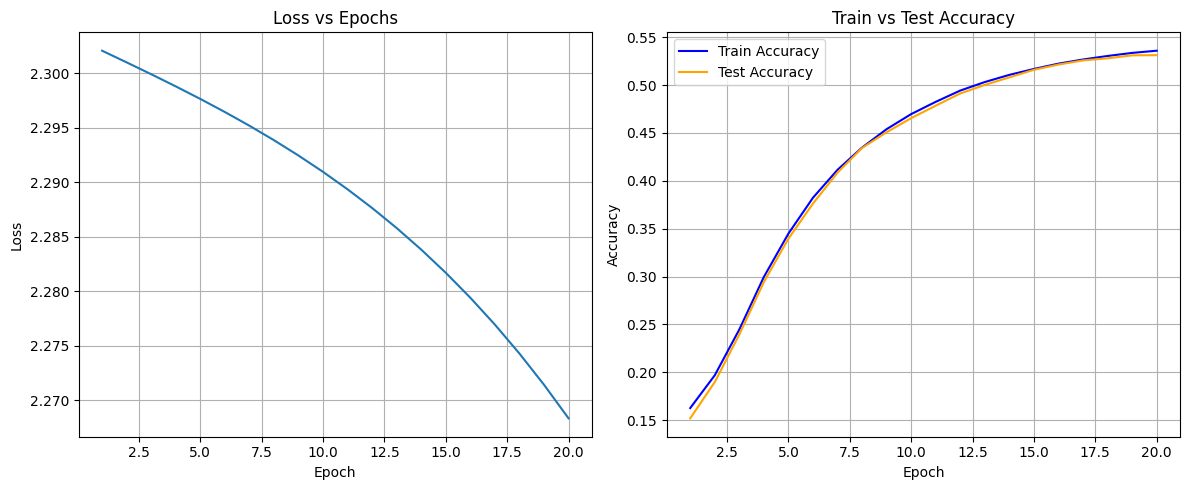

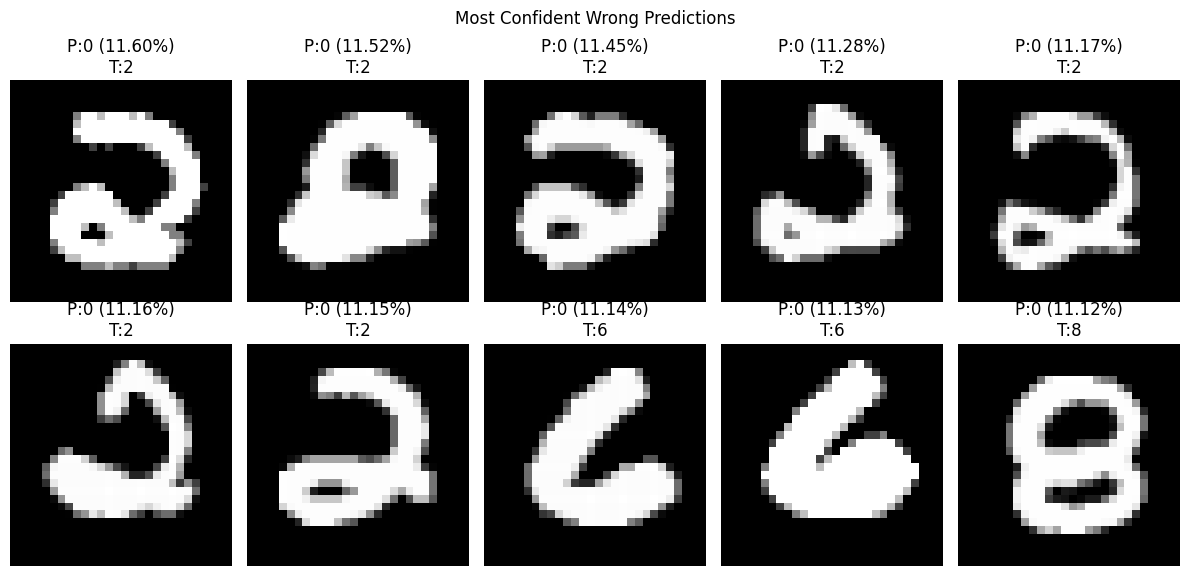

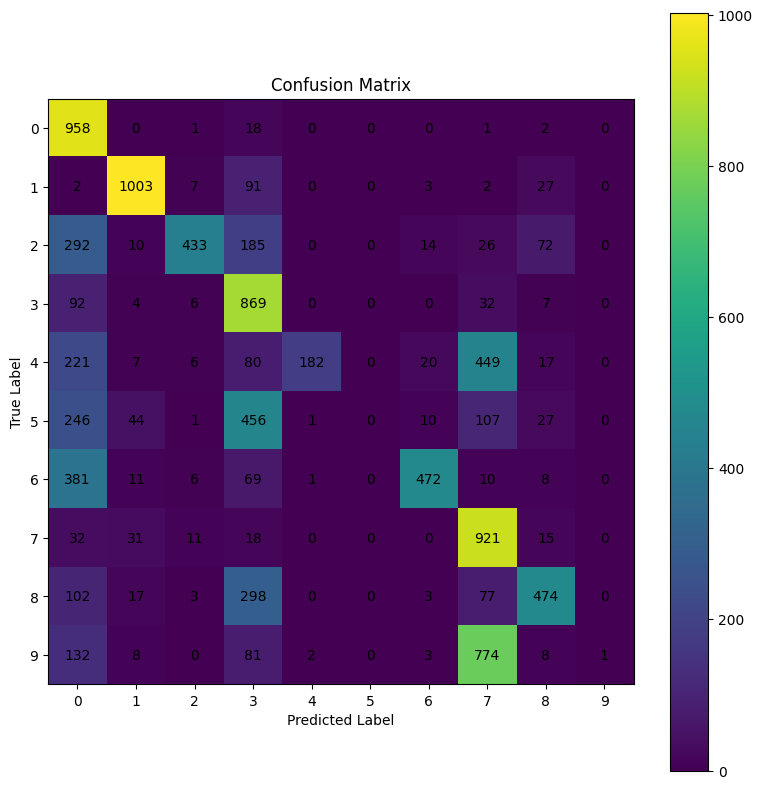

In [107]:
plot_helper(20, 0.1)

### For epochs = 20 | Learning rate = 0.01

Epoch 1 | Loss: 2.3027 | Train: 0.1252 | Test: 0.1249
Epoch 2 | Loss: 2.3025 | Train: 0.1263 | Test: 0.1257
Epoch 3 | Loss: 2.3024 | Train: 0.1275 | Test: 0.1276
Epoch 4 | Loss: 2.3023 | Train: 0.1286 | Test: 0.1285
Epoch 5 | Loss: 2.3022 | Train: 0.1298 | Test: 0.1307
Epoch 6 | Loss: 2.3021 | Train: 0.1310 | Test: 0.1321
Epoch 7 | Loss: 2.3020 | Train: 0.1321 | Test: 0.1329
Epoch 8 | Loss: 2.3019 | Train: 0.1332 | Test: 0.1354
Epoch 9 | Loss: 2.3018 | Train: 0.1353 | Test: 0.1374
Epoch 10 | Loss: 2.3017 | Train: 0.1369 | Test: 0.1391
Epoch 11 | Loss: 2.3016 | Train: 0.1384 | Test: 0.1411
Epoch 12 | Loss: 2.3015 | Train: 0.1402 | Test: 0.1434
Epoch 13 | Loss: 2.3013 | Train: 0.1419 | Test: 0.1447
Epoch 14 | Loss: 2.3012 | Train: 0.1434 | Test: 0.1465
Epoch 15 | Loss: 2.3011 | Train: 0.1449 | Test: 0.1476
Epoch 16 | Loss: 2.3010 | Train: 0.1462 | Test: 0.1496
Epoch 17 | Loss: 2.3009 | Train: 0.1481 | Test: 0.1525
Epoch 18 | Loss: 2.3008 | Train: 0.1498 | Test: 0.1549
Epoch 19 | Loss: 2.

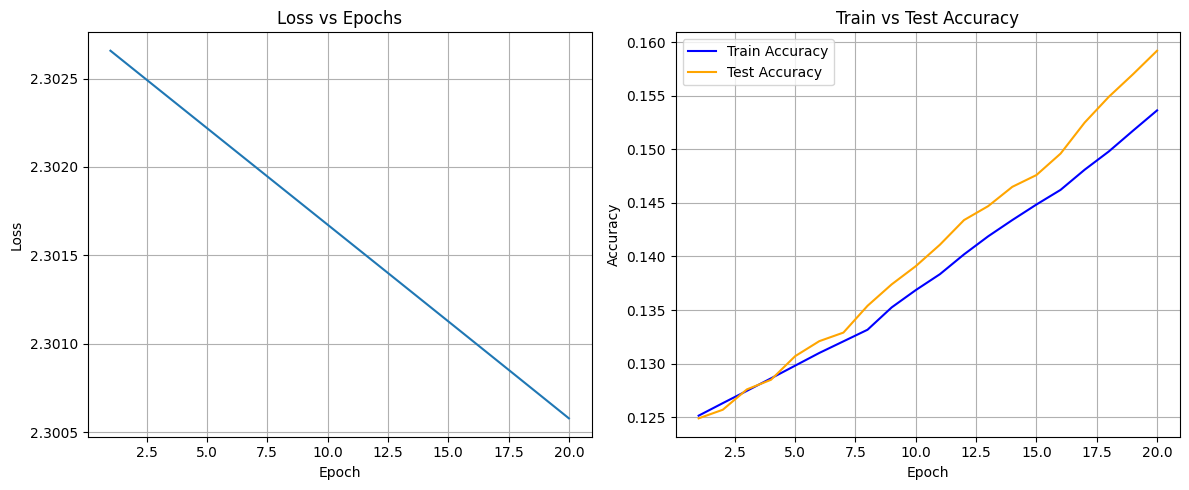

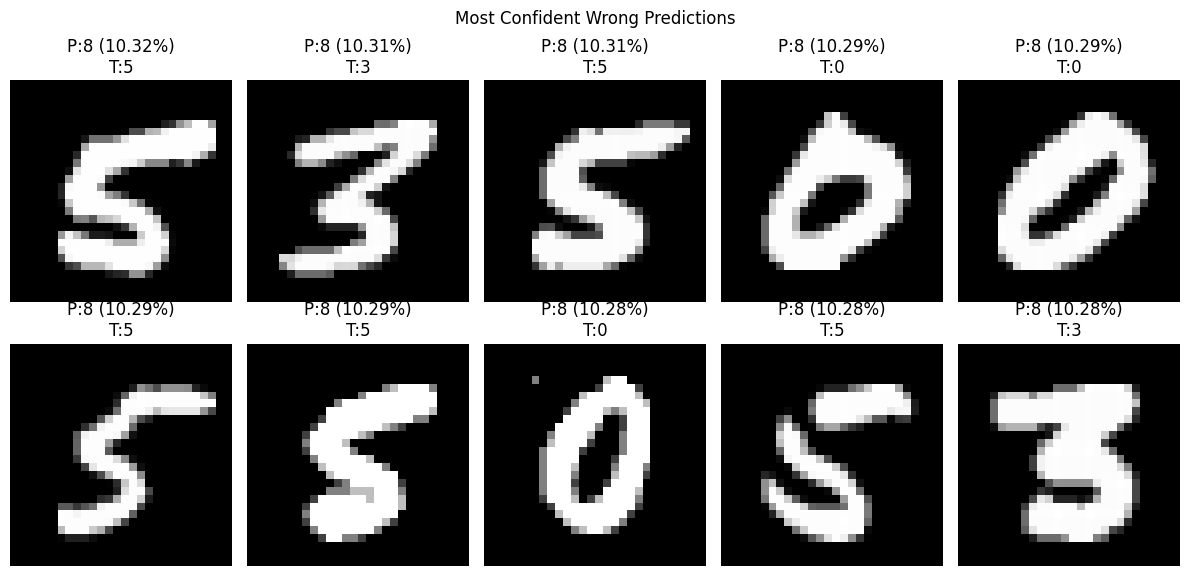

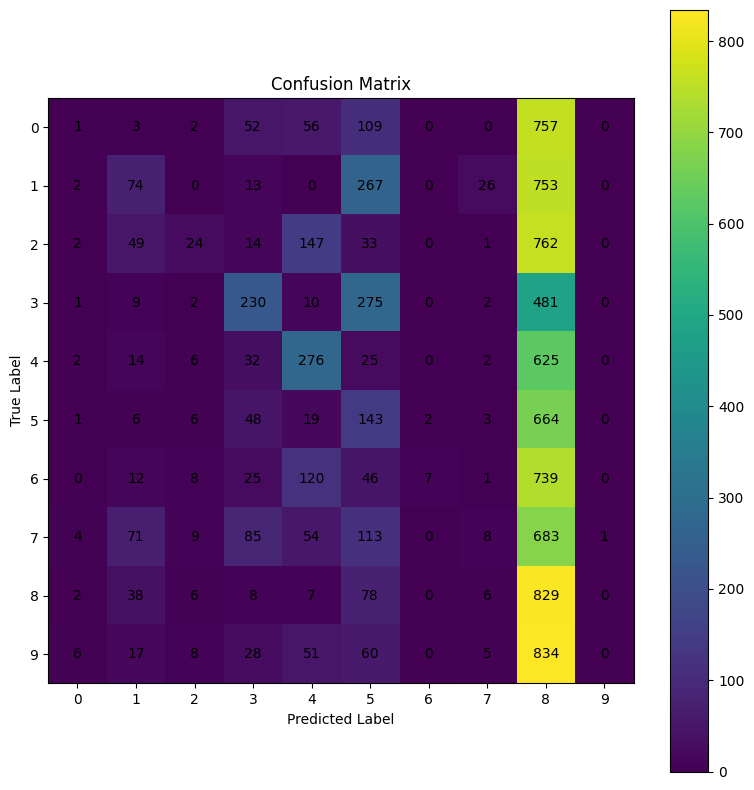

In [108]:
plot_helper(20, 0.01)

### For epochs = 50 | Learning rate = 0.1

Epoch 10 | Loss: 2.2928 | Train: 0.2503 | Test: 0.2553
Epoch 20 | Loss: 2.2741 | Train: 0.3455 | Test: 0.3461
Epoch 30 | Loss: 2.2342 | Train: 0.3996 | Test: 0.4039
Epoch 40 | Loss: 2.1525 | Train: 0.4315 | Test: 0.4349
Epoch 50 | Loss: 2.0102 | Train: 0.5190 | Test: 0.5243


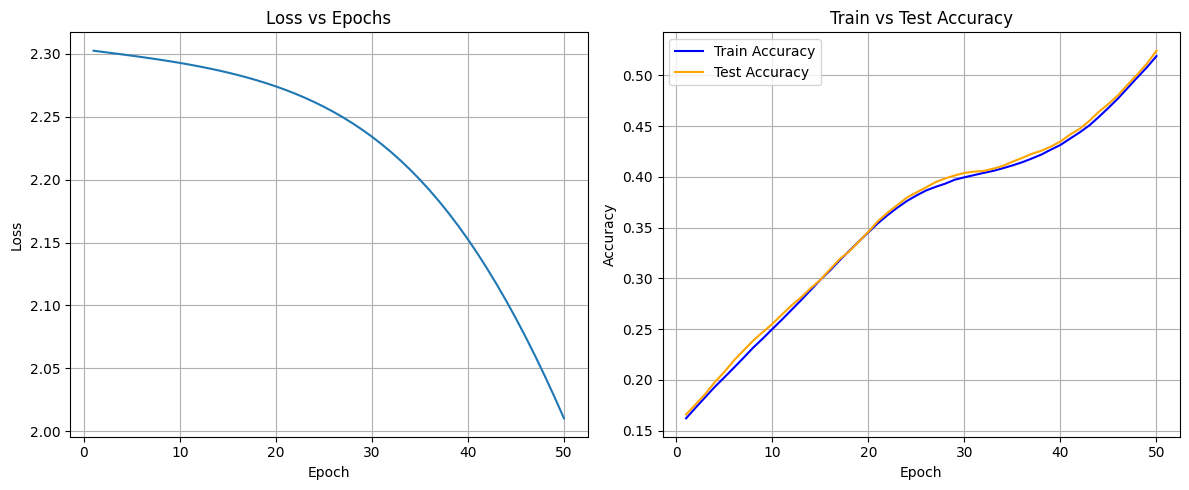

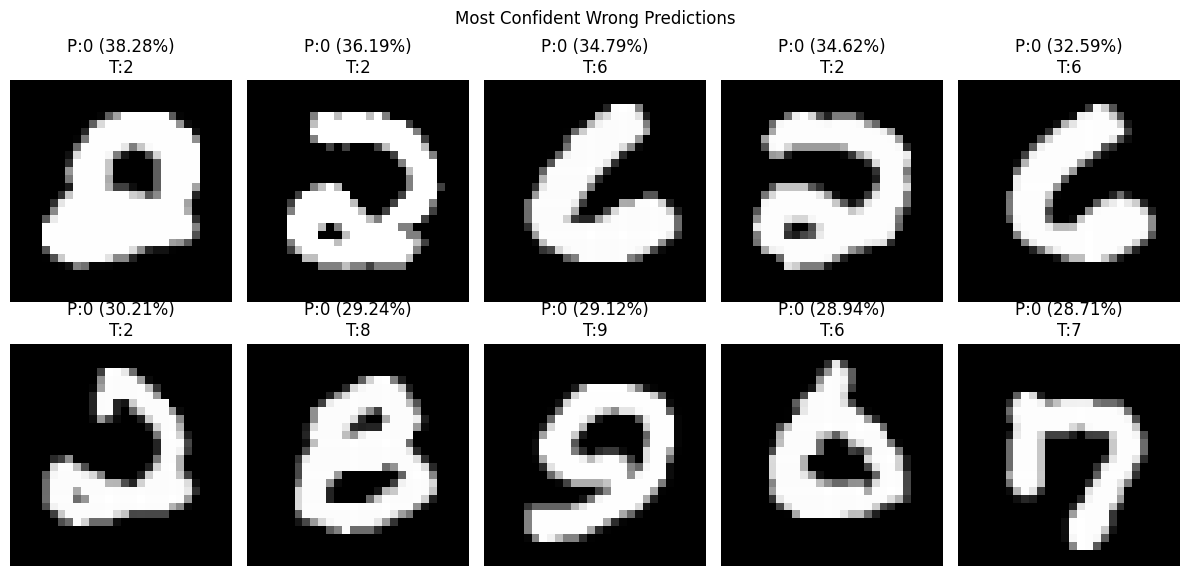

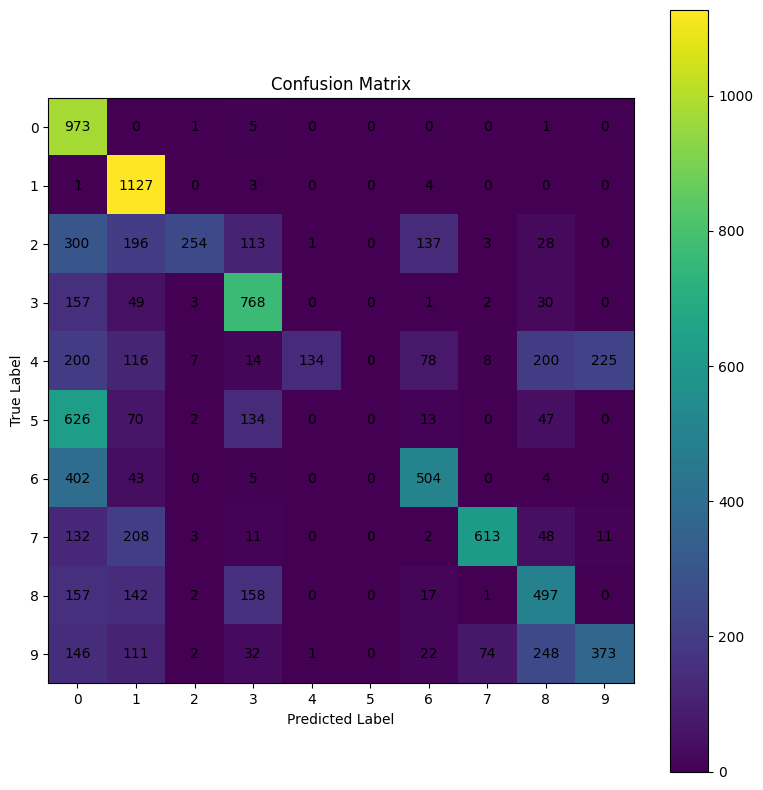

In [109]:
plot_helper(50, 0.1)

### For epochs = 50 | Learning rate = 0.001

Epoch 10 | Loss: 2.3026 | Train: 0.0925 | Test: 0.0880
Epoch 20 | Loss: 2.3025 | Train: 0.0947 | Test: 0.0899
Epoch 30 | Loss: 2.3024 | Train: 0.0966 | Test: 0.0919
Epoch 40 | Loss: 2.3022 | Train: 0.0988 | Test: 0.0939
Epoch 50 | Loss: 2.3021 | Train: 0.1012 | Test: 0.0971


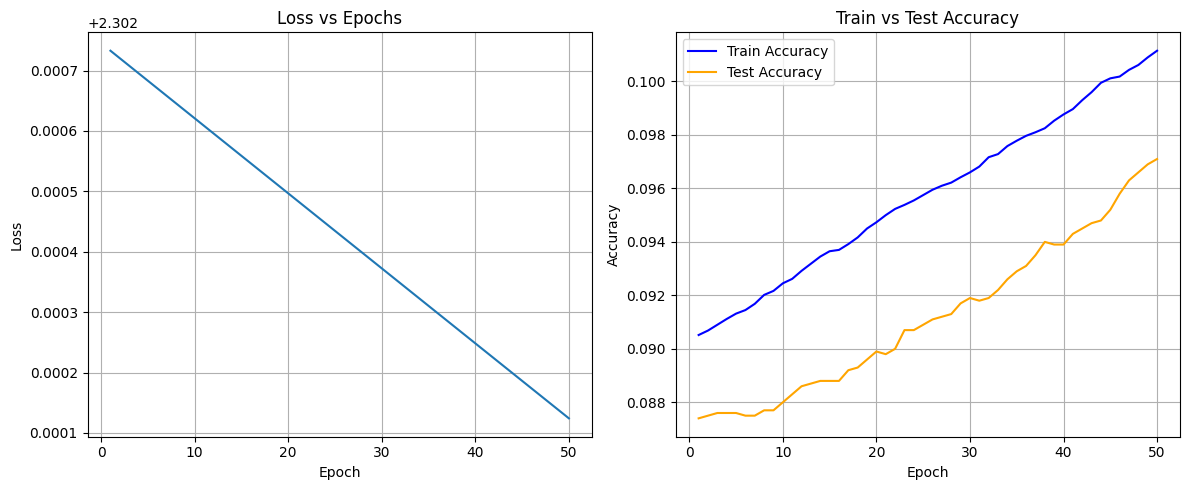

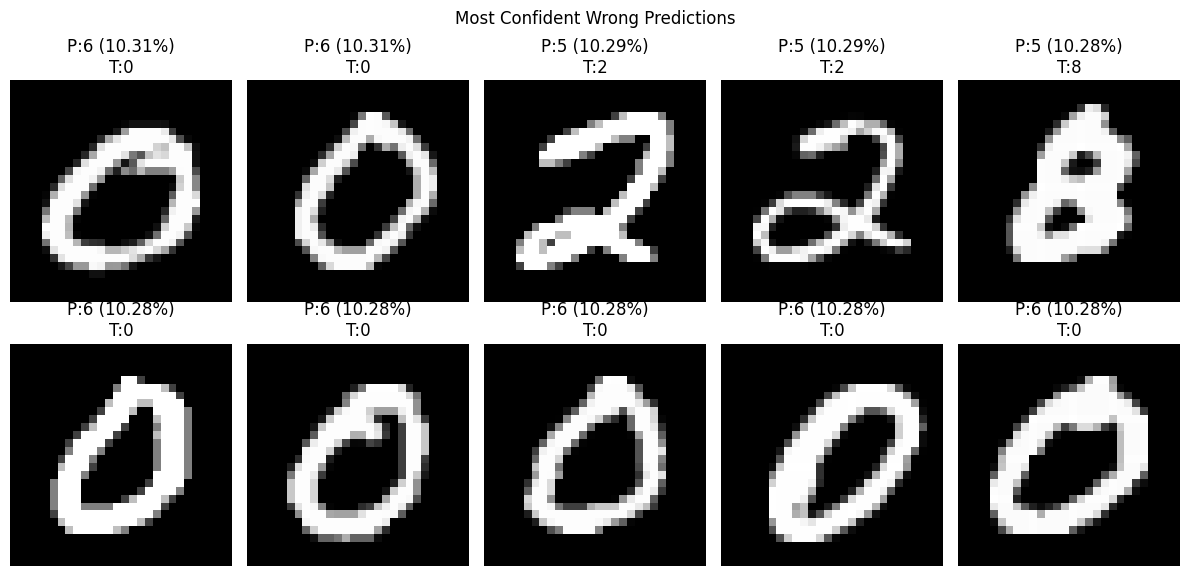

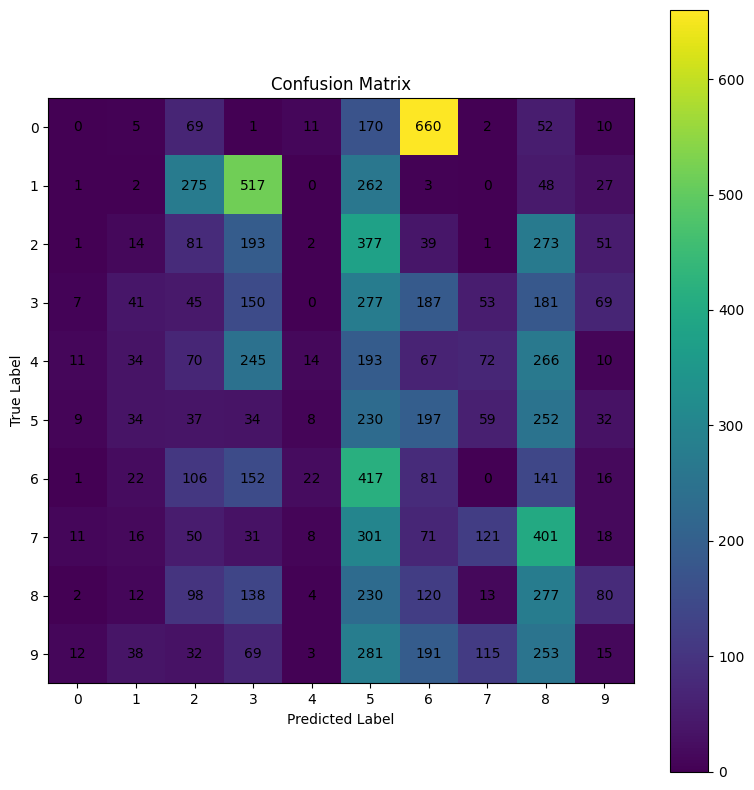

In [110]:
plot_helper(50, 0.001)

### For epoch = 300 | Learning rate = 0.1

Epoch 10 | Loss: 2.2925 | Train: 0.3037 | Test: 0.3096
Epoch 20 | Loss: 2.2734 | Train: 0.4653 | Test: 0.4731
Epoch 30 | Loss: 2.2336 | Train: 0.5228 | Test: 0.5297
Epoch 40 | Loss: 2.1527 | Train: 0.5696 | Test: 0.5835
Epoch 50 | Loss: 2.0077 | Train: 0.6431 | Test: 0.6536
Epoch 60 | Loss: 1.7898 | Train: 0.6896 | Test: 0.6948
Epoch 70 | Loss: 1.5291 | Train: 0.7068 | Test: 0.7148
Epoch 80 | Loss: 1.2871 | Train: 0.7316 | Test: 0.7398
Epoch 90 | Loss: 1.0972 | Train: 0.7641 | Test: 0.7738
Epoch 100 | Loss: 0.9564 | Train: 0.7876 | Test: 0.7937
Epoch 110 | Loss: 0.8520 | Train: 0.8044 | Test: 0.8074
Epoch 120 | Loss: 0.7733 | Train: 0.8173 | Test: 0.8205
Epoch 130 | Loss: 0.7125 | Train: 0.8269 | Test: 0.8305
Epoch 140 | Loss: 0.6644 | Train: 0.8351 | Test: 0.8394
Epoch 150 | Loss: 0.6255 | Train: 0.8427 | Test: 0.8463
Epoch 160 | Loss: 0.5934 | Train: 0.8493 | Test: 0.8535
Epoch 170 | Loss: 0.5664 | Train: 0.8548 | Test: 0.8588
Epoch 180 | Loss: 0.5433 | Train: 0.8598 | Test: 0.8639
E

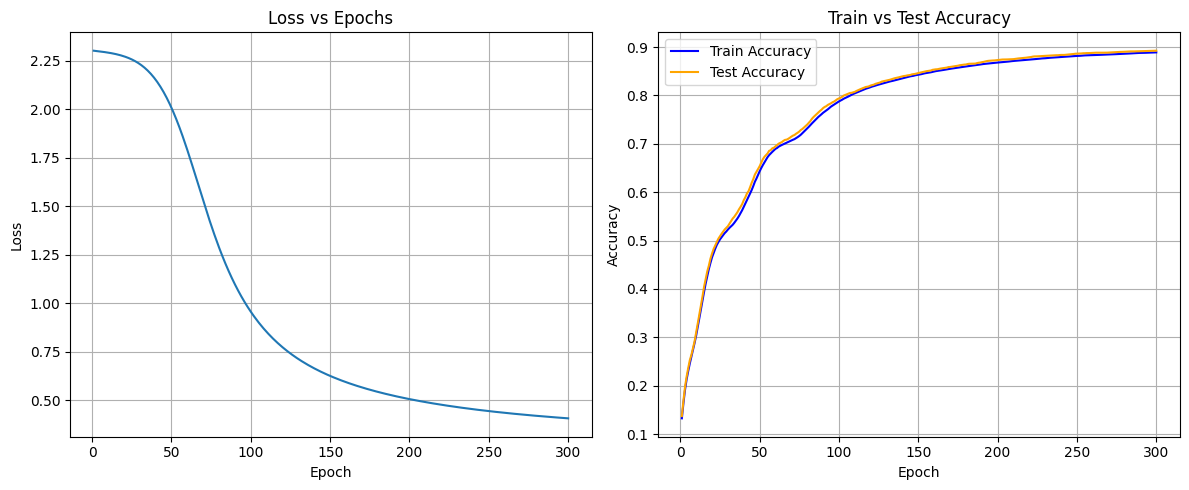

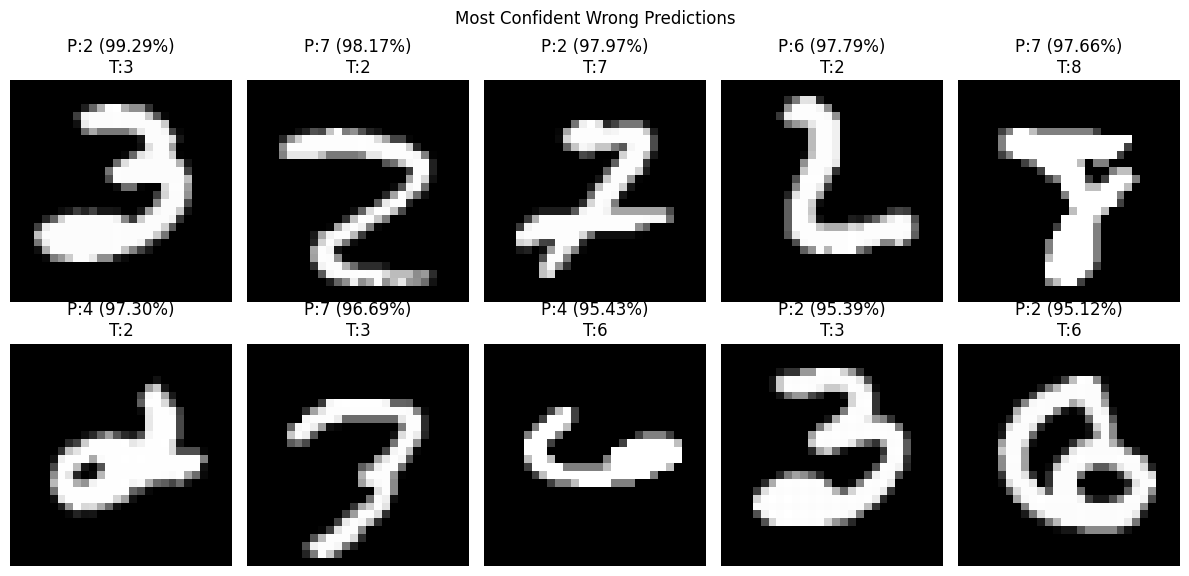

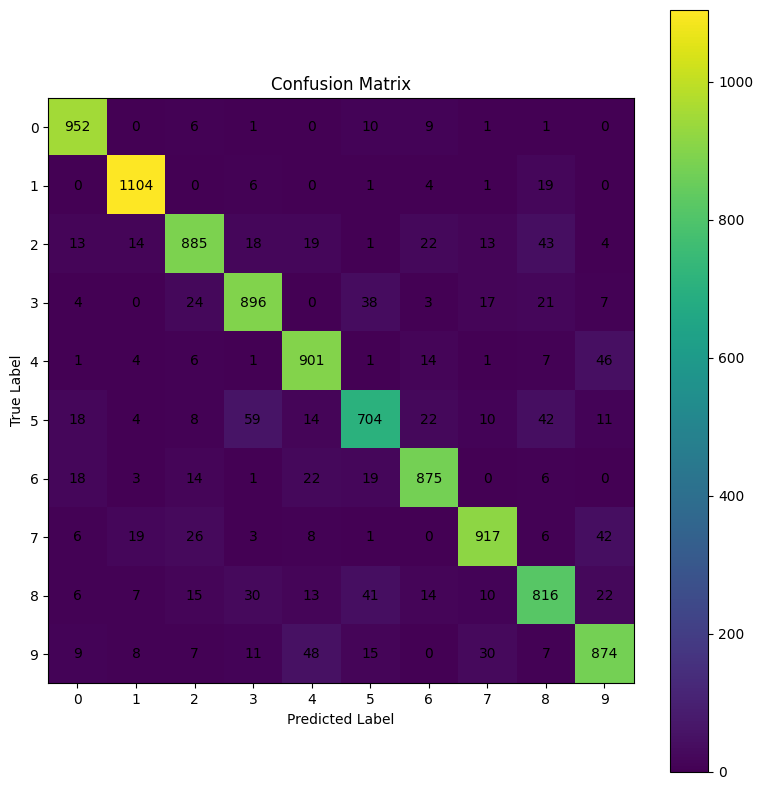

In [111]:
plot_helper(300, 0.1)

---

### Conclusion
Several combinations of learning rates and epochs were evaluated to study their effect on the performance of a neural network trained from scratch on the MNIST dataset.

The experiments showed that the learning rate had a much greater impact on model performance than simply increasing the number of training epochs. A learning rate of _0.001_ resulted in _very slow learning_, causing the network to converge to a poor solution where it predicted a single class for most inputs and achieved _approximately 10% accuracy_. Increasing the number of epochs alone was not sufficient to overcome this issue.

When the learning rate was increased to _0.1_, the model learned _significantly faster_ and achieved substantially higher training and test accuracy within fewer epochs. This demonstrates that an appropriately chosen learning rate enables the optimizer to make meaningful progress through the parameter space, whereas an excessively small learning rate can prevent effective learning even after many training iterations.

The train and test accuracy curves remained close throughout training, indicating that the model was _primarily underfitting rather than overfitting_. The confusion matrices and analysis of incorrect predictions further revealed how the network's classification ability improved as optimization became more effective.

Overall, these experiments highlight the importance of hyperparameter tuning in neural network training. Among the parameters explored, the learning rate proved to be the most influential factor affecting convergence speed and final model performance.

---